ValueError: '' is not a valid value for cmap.
See `matplotlib.bivar_colormaps()` and `matplotlib.multivar_colormaps()` for bivariate and multivariate colormaps

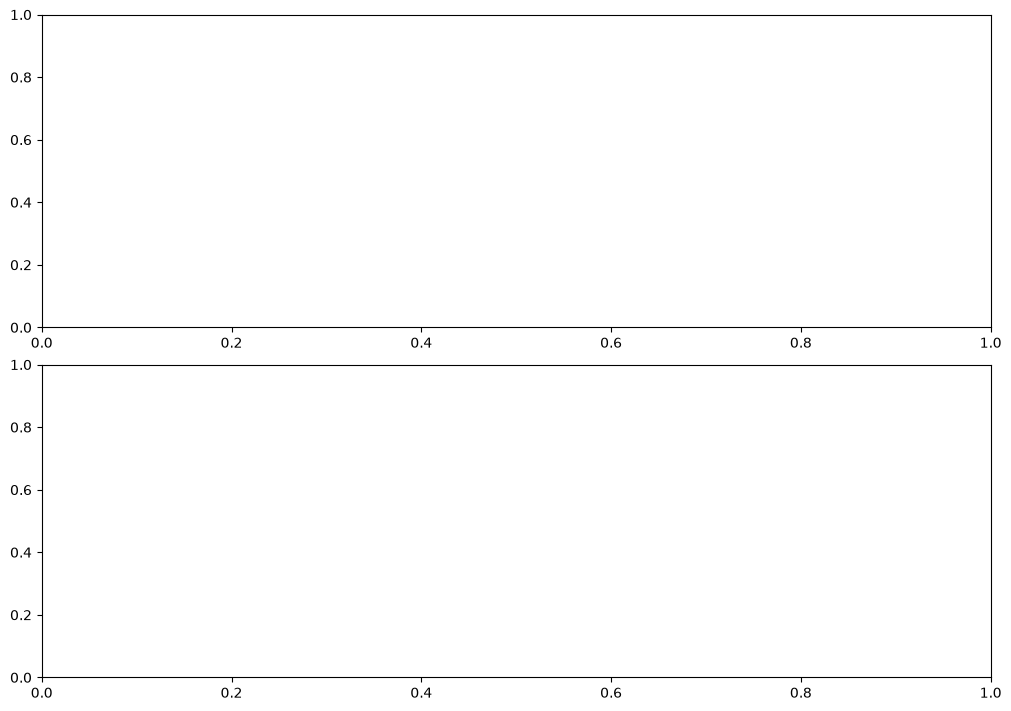

In [ ]:
import os
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Set seed for reproducible file selection
SEED = 7
random.seed(SEED)

# 1. Define folder paths
dir_1 = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Call_Library/1 - positive target'
dir_0 = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Call_Library/0 - negative target'

# 2. Get list of audio files
files_1 = [f for f in os.listdir(dir_1) if f.lower().endswith(('.wav', '.flac'))]
files_0 = [f for f in os.listdir(dir_0) if f.lower().endswith(('.wav', '.flac'))]

file_1_path = os.path.join(dir_1, random.choice(files_1))
file_0_path = os.path.join(dir_0, random.choice(files_0))

# 3. Helper function to plot Mel spectrograms with customized ticks
def plot_spectrogram(ax, audio_path, title, fmin=20000, fmax=100000):
    y, sr = librosa.load(audio_path, sr=None)
    
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=2048, hop_length=512, 
        n_mels=256, fmin=fmin, fmax=fmax
    )
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    img = librosa.display.specshow(
        S_dB, sr=sr, hop_length=512, x_axis='time', y_axis='mel', 
        fmin=fmin, fmax=fmax, ax=ax, cmap='magma'
    )
    
    # --- CUSTOM Y-AXIS (FREQUENCY: 20 kHz to 100 kHz in 10 kHz steps) ---
    y_ticks = np.arange(fmin, fmax + 1, 10000)  # [20000, 30000, ..., 100000]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{int(f/1000)}" for f in y_ticks])  # Displays ['20', '30', ..., '100']
    ax.set_ylabel('Frequency (kHz)', fontsize=9, fontweight='bold')
    
    # --- CUSTOM X-AXIS (TIME: 0.0s to 0.5s in 0.1s steps) ---
    x_ticks = np.arange(0.0, 0.51, 0.1)  # [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x:.1f}" for x in x_ticks])
    ax.set_xlabel('Time (s)', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    return img

# 4. Create 2-panel figure with constrained_layout
fig, axs = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True)

img1 = plot_spectrogram(axs[0], file_1_path, "Saccopteryx bilineata  (Positive Label 1)")
img2 = plot_spectrogram(axs[1], file_0_path, "Non-Target (Negative / Label 0)")

# 5. Add shared colorbar locked to the right side
cbar = fig.colorbar(img2, ax=axs, location='right', shrink=0.85, pad=0.02)
cbar.set_label('Relative Power (dB)', fontsize=10, fontweight='bold')

plt.show()